# Practical No. 02: Text Classification using Embedding Layer and LSTM

## Aim
To build a **multiclass text classification model** using an **Embedding layer** and an **LSTM network**, and evaluate the model performance using appropriate classification metrics.

## Dataset
**Kaggle Emotions Dataset by Bhavik Jikadara**

The dataset contains text samples belonging to six emotion classes:
- 0 → Sadness
- 1 → Joy
- 2 → Love
- 3 → Anger
- 4 → Fear
- 5 → Surprise

## Model Pipeline
Text → Cleaning → Label Encoding → Tokenization → Padding → Embedding → LSTM → Dropout → Dense + Softmax → Emotion

## 1. Import Required Libraries

We use:
- **Pandas / NumPy** for data handling
- **Matplotlib / Seaborn** for visualization
- **TensorFlow / Keras** for the Embedding + LSTM model
- **Scikit-learn** for train-test splitting and classification metrics

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load the Dataset

Place `emotions.csv` in the same folder as this notebook.

The uploaded Kaggle file contains two columns:
- `text` — input sentence
- `label` — emotion class

In [27]:
df = pd.read_csv("emotions.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (416809, 2)


,text,label
0,i just feel really helpless and heavy hearted,4
1,ive enjoyed being able to slouch about relax a...,0
2,i gave up my internship with the dmrg and am f...,4
3,i dont know i feel so lost,0
4,i am a kindergarten teacher and i am thoroughl...,4


## 3. Explore the Dataset

In [28]:
print("Column names:", df.columns.tolist())
print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

print("\nNumber of unique text samples:", df["text"].nunique())
print("Number of emotion classes:", df["label"].nunique())

Column names: ['text', 'label']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416809 entries, 0 to 416808
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    416809 non-null  object
 1   label   416809 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 6.4+ MB

Missing values:
text     0
label    0
dtype: int64

Number of duplicate rows: 686

Number of unique text samples: 393822
Number of emotion classes: 6


## 4. Clean the Dataset

In [29]:
# Remove missing values
df = df.dropna(subset=["text", "label"])

# Remove duplicate rows
df = df.drop_duplicates(subset=["text", "label"])

# Make sure text is string
df["text"] = df["text"].astype(str)

# Keep labels as integers
df["label"] = df["label"].astype(int)

df = df.reset_index(drop=True)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (416123, 2)


## 5. Emotion Class Distribution

The dataset is multiclass and contains six emotion labels. We visualize the distribution before training.

emotion
Joy         140779
Sadness     120989
Anger        57235
Fear         47664
Love         34497
Surprise     14959
Name: count, dtype: int64


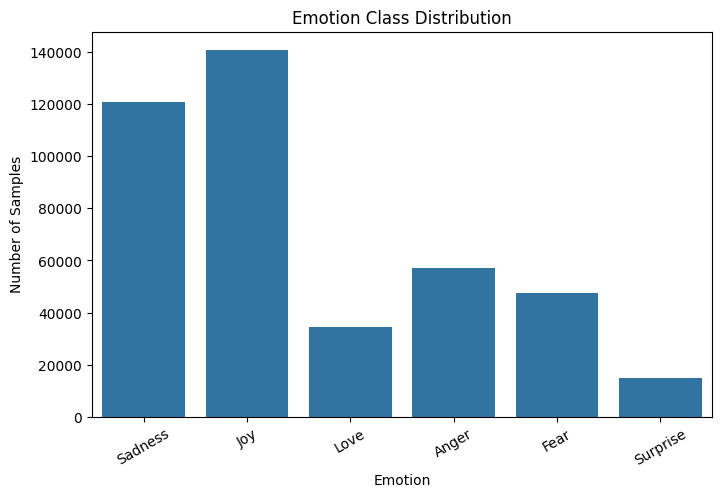

In [30]:
emotion_names = {
    0: "Sadness",
    1: "Joy",
    2: "Love",
    3: "Anger",
    4: "Fear",
    5: "Surprise"
}

df["emotion"] = df["label"].map(emotion_names)

print(df["emotion"].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="emotion", order=list(emotion_names.values()))
plt.title("Emotion Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30)
plt.show()

## 6. Display Sample Texts from Each Class

In [31]:
for label, emotion in emotion_names.items():
    print(f"\n{label} - {emotion}")
    samples = df[df["label"] == label]["text"].head(3)
    for text in samples:
        print("•", text)


0 - Sadness
• ive enjoyed being able to slouch about relax and unwind and frankly needed it after those last few weeks around the end of uni and the expo i have lately started to find myself feeling a bit listless which is never really a good thing
• i dont know i feel so lost
• i was beginning to feel quite disheartened

1 - Joy
• i fear that they won t ever feel that delicious excitement of christmas eve at least not in the same way i remember doing it
• i try to be nice though so if you get a bitchy person on the phone or at the window feel free to have a little fit and throw your pen at her face
• i have officially graduated im not feeling as ecstatic as i thought i would

2 - Love
• i would think that whomever would be lucky enough to stay in this suite must feel like it is the most romantic place on earth
• i guess that feeling is what im really getting all nostalgic about
• i was less intelligent and could not really feel through my music was not passionate about the little thi

## 7. Prepare Input and Output

`X` contains the text and `y` contains the numerical emotion labels.

In [32]:
X = df["text"].values
y = df["label"].values

print("Number of text samples:", len(X))
print("Number of labels:", len(y))

Number of text samples: 416123
Number of labels: 416123


## 8. Create Train-Test Split

We use **80% of the data for training and 20% for testing**.

`stratify=y` keeps the class proportions approximately the same in both sets.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 332898
Testing samples: 83225


## 9. Tokenization

The Embedding layer works with integer token IDs rather than raw text.

The tokenizer builds a vocabulary from the training text. `oov_token` represents words that were not seen during training.

In [34]:
MAX_WORDS = 20000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)

print("Total words found:", len(tokenizer.word_index))
print("Vocabulary used by model:", vocab_size)

print("\nOriginal text:")
print(X_train[0])

print("\nTokenized sequence:")
print(X_train_sequences[0])

Total words found: 67889
Vocabulary used by model: 20000

Original text:
i feel loved a href http thesmallhousefamily

Tokenized sequence:
[2, 3, 259, 7, 199, 179, 1]


## 10. Sequence Padding

LSTM networks process sequences, but neural-network batches require sequences with the same length.

We use a maximum sequence length of 50. Shorter sequences are padded with zeros and longer sequences are truncated.

In [35]:
MAX_LENGTH = 50

X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Training data shape:", X_train_padded.shape)
print("Testing data shape:", X_test_padded.shape)

print("\nExample padded sequence:")
print(X_train_padded[0])

Training data shape: (332898, 50)
Testing data shape: (83225, 50)

Example padded sequence:
[  2   3 259   7 199 179   1   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


# 11. Build the Embedding + LSTM Model

### Architecture

**Embedding → LSTM → Dropout → Dense(Softmax)**

- **Embedding:** learns a dense vector representation of words.
- **LSTM:** learns sequential/contextual information from the text.
- **Dropout:** helps reduce overfitting.
- **Dense + Softmax:** predicts one of the six emotion classes.

In [36]:
EMBEDDING_DIM = 128
LSTM_UNITS = 64
NUM_CLASSES = 6

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM
    ),
    LSTM(LSTM_UNITS),
    Dropout(0.30),
    Dense(NUM_CLASSES, activation="softmax")
])

model.build(input_shape=(None, MAX_LENGTH))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609,798 (9.96 MB)

 Trainable params: 2,609,798 (9.96 MB)

 Non-trainable params: 0 (0.00 B)

## 12. Compile the Model

Since this is a **multiclass classification** problem with integer class labels, we use:
- Optimizer: **Adam**
- Loss: **Sparse Categorical Crossentropy**
- Metric: **Accuracy**

In [37]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## 13. Train the Model

Early stopping stops training when validation loss stops improving and restores the best model weights.

The validation split is taken from the training data; the test set remains untouched until final evaluation.

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_padded,
    y_train,
    validation_split=0.10,
    epochs=10,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
2341/2341 ━━━━━━━━━━━━━━━━━━━━ 332s 142ms/step - accuracy: 0.9409 - loss: 0.0935 - val_accuracy: 0.9347 - val_loss: 0.1058
Epoch 2/10
  98/2341 ━━━━━━━━━━━━━━━━━━━━ 4:13 113ms/step - accuracy: 0.9398 - loss: 0.0931

## 14. Plot Training and Validation Accuracy

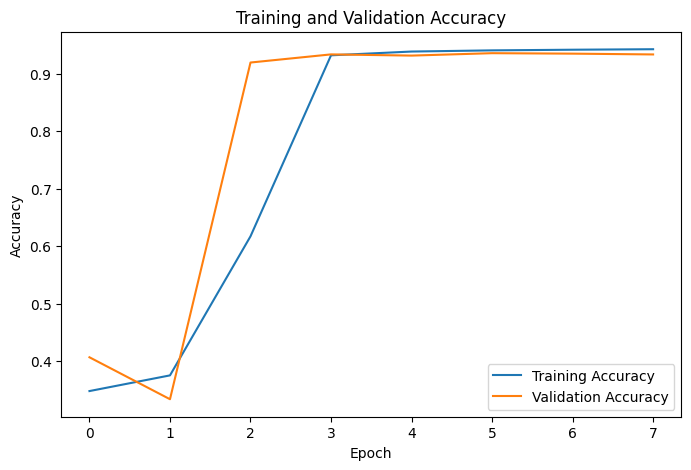

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 15. Plot Training and Validation Loss

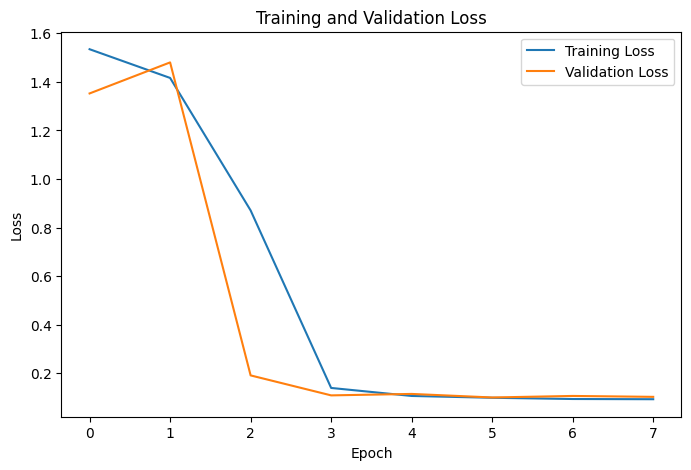

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 16. Evaluate the Model on Test Data

The test set is used only after training to estimate how well the model generalizes to unseen text.

In [41]:
test_loss, test_accuracy = model.evaluate(
    X_test_padded,
    y_test,
    verbose=0
)

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

Test Loss     : 0.09681391716003418
Test Accuracy : 0.9382757544517517


## 17. Generate Predictions

The Softmax layer produces six probabilities for each test sentence. `argmax` selects the class with the highest probability.

In [42]:
y_probability = model.predict(X_test_padded, batch_size=128, verbose=1)
y_pred = np.argmax(y_probability, axis=1)

print("First 20 actual labels:    ", y_test[:20])
print("First 20 predicted labels:", y_pred[:20])

651/651 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step
First 20 actual labels:     [0 0 1 1 3 1 0 2 1 1 3 1 4 0 3 3 2 0 3 1]
First 20 predicted labels: [0 0 1 1 3 1 0 2 1 1 3 1 4 0 3 4 0 0 3 1]


# 18. Classification Metrics

We evaluate the model using:
- **Accuracy:** overall percentage of correct predictions.
- **Precision:** how many predicted samples of a class are actually that class.
- **Recall:** how many actual samples of a class were correctly identified.
- **F1-score:** harmonic mean of precision and recall.

For the overall multiclass scores, we use the **weighted average**, which accounts for the number of samples in each class.

In [43]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("Classification Metrics")
print("----------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Classification Metrics
----------------------
Accuracy  : 0.9383
Precision : 0.9411
Recall    : 0.9383
F1-Score  : 0.9371


## 19. Classification Report

In [44]:
report = classification_report(
    y_test,
    y_pred,
    labels=list(emotion_names.keys()),
    target_names=list(emotion_names.values()),
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

     Sadness       0.97      0.98      0.97     24198
         Joy       0.93      0.99      0.96     28156
        Love       0.99      0.72      0.83      6899
       Anger       0.97      0.91      0.94     11447
        Fear       0.91      0.87      0.89      9533
    Surprise       0.76      0.93      0.83      2992

    accuracy                           0.94     83225
   macro avg       0.92      0.90      0.90     83225
weighted avg       0.94      0.94      0.94     83225



## 20. Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions for every emotion class.

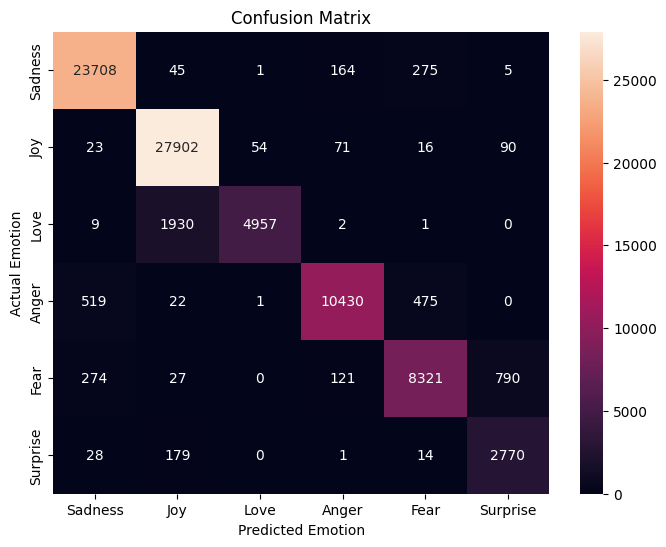

In [45]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=list(emotion_names.keys())
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=list(emotion_names.values()),
    yticklabels=list(emotion_names.values())
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.show()

# 21. Test the Model with New Sentences

The trained tokenizer and model can now classify completely new text.

In [46]:
def predict_emotion(text):
    sequence = tokenizer.texts_to_sequences([text])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    probabilities = model.predict(padded_sequence, verbose=0)[0]
    predicted_label = int(np.argmax(probabilities))

    emotion = emotion_names[predicted_label]
    confidence = float(probabilities[predicted_label] * 100)

    return emotion, confidence


test_sentences = [
    "I am extremely happy today.",
    "I feel very sad and lonely.",
    "I am scared about what will happen.",
    "I am so angry right now.",
    "I really love this person.",
    "Wow, I did not expect that!"
]

for sentence in test_sentences:
    emotion, confidence = predict_emotion(sentence)
    print("Text:", sentence)
    print(f"Predicted Emotion: {emotion}")
    print(f"Confidence: {confidence:.2f}%")
    print("-" * 60)

Text: I am extremely happy today.
Predicted Emotion: Joy
Confidence: 87.59%
------------------------------------------------------------
Text: I feel very sad and lonely.
Predicted Emotion: Sadness
Confidence: 99.99%
------------------------------------------------------------
Text: I am scared about what will happen.
Predicted Emotion: Fear
Confidence: 54.54%
------------------------------------------------------------
Text: I am so angry right now.
Predicted Emotion: Anger
Confidence: 75.06%
------------------------------------------------------------
Text: I really love this person.
Predicted Emotion: Anger
Confidence: 35.12%
------------------------------------------------------------
Text: Wow, I did not expect that!
Predicted Emotion: Fear
Confidence: 29.92%
------------------------------------------------------------


# 22. Final Performance Summary

In [47]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
})

display(results)

,Metric,Score
0,Accuracy,0.938276
1,Precision,0.941109
2,Recall,0.938276
3,F1-Score,0.937071


# 23. Conclusion

A **multiclass text classification model** was successfully built using an **Embedding layer and an LSTM network** on the Kaggle Emotion Dataset.

The text data was cleaned, tokenized, converted into numerical sequences, and padded to a fixed length. The Embedding layer learned dense word representations, while the LSTM layer learned sequential patterns in the text.

The model classified text into six emotion categories: **Sadness, Joy, Love, Anger, Fear, and Surprise**.

The model was evaluated using **Accuracy, Precision, Recall, F1-Score, Classification Report, and Confusion Matrix**.

Thus, the practical successfully demonstrates **text classification using an Embedding layer and LSTM network**.

#Submitted by :

PRN : 2025021100008

Name :Dhanashri Abhijit Shah